<a href="https://colab.research.google.com/github/mezad2003-cmd/Vision-artificial/blob/main/notebooks/assignment_01_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Introduction to projective geometry

Andrés Marrugo, PhD    
Universidad Tecnológica de Bolívar    

Adapted from Magnus Oskarsson, Lund University

In this homework we will study the representation of points, lines and planes, and also their transformations under projection.

The exercises are to be solved by "hand" although you may write the answers in markdown/LaTex or include a snapshot of your solution. The computer exercises are to be solved in the corresponding code cell. Enjoy!

## Points in Homogeneous Coordinates

### Exercise 1

 What is the 2D Cartesian coordinates of the points with homogeneous coordinates

\begin{align}
\mathbf{x_1} = \left(
\begin{array}{c}
4\\
-2\\
2\\
\end{array}
\right)
,\enspace
\mathbf{x_2} = \left(
\begin{array}{c}
3\\
-2\\
-1\\
\end{array}
\right)
, \enspace \text{and }
\mathbf{x_3} = \left(
\begin{array}{c}
4\lambda\\
-2\lambda\\
2\lambda\\
\end{array}
\right)
,\enspace
\lambda \neq 0?
\end{align}


What is the interpretation of the point with homogeneous coordinates

\begin{align}
\mathbf{x_4} = \left(
\begin{array}{c}
4\\
-2\\
0\\
\end{array}
\right)
\enspace?
\end{align}

*For the report: Answers are enough.*


### Computer Exercise 1.
Write a Python function `pflat` that divides the homogeneous coordinates with their last entry for points of any dimensionality. (You may assume that none of the points have last homogeneous coordinate zero.) Apply the function to the points in `x2D` and `x3D` in the file `compEx1.npz`, and plot the result.

In [1]:
import numpy as np
import pandas as pd
import urllib.request
import cv2 as cv
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from PIL import Image
import matplotlib.pyplot as plt


In [8]:
DATA_URL = 'https://github.com/agmarrugo/computer-vision-utb/blob/main/data/compEx1.npz?raw=true'

urllib.request.urlretrieve(DATA_URL, 'compEx1.npz')

data = np.load('compEx1.npz')

x2D = data['x2D']
x3D = data['x3D']

# print(x2D)
# print(x3D)


Forma x2Dn: (2, 63)
Forma x3Dn: (3, 441)


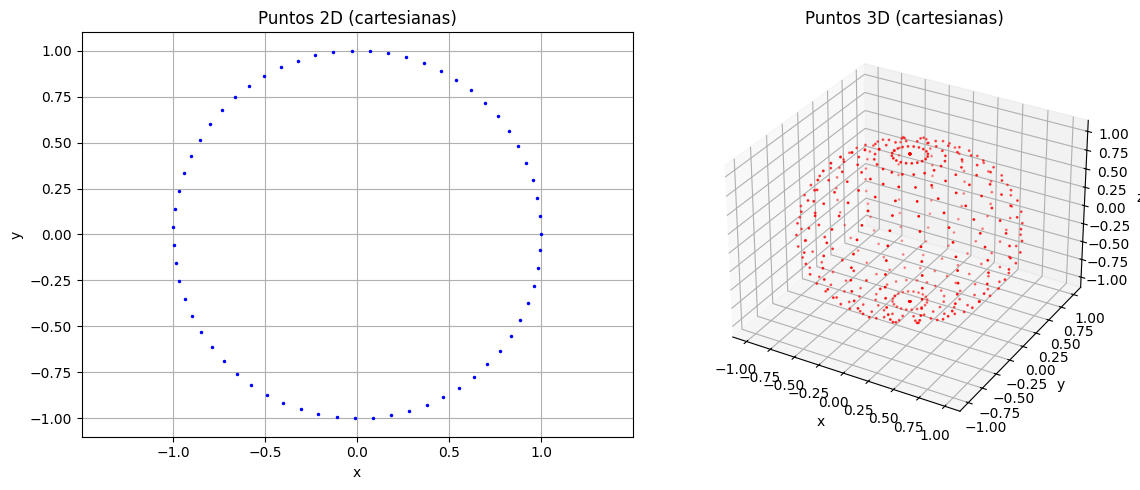

In [6]:
# Computer Exercise 1 - Solution.

def pflat(hx):
  ''' pflat - Normalizes array of homogeneous coordinates (2D or 3D) and converts
      to cartesian (inhomogeneous) coordinates.

      Usage:  x = pflat(hx)
      Argument:
          hx  - an N x npts array of homogeneous coordinates.
      Returns:
          x - an (N-1) x npts array of cartesian (inhomogeneous) coordinates
  '''
  x = hx[:-1] / hx[-1]
  return x

  # write your code here.
  # Useful commands:
  # hx[-1] : indexes the last row of the array
  # x[:-1] : indexes all rows except the last one

  # return x

# After defining the pflat function try it on the x2D and x3D points
# x2Dn = pflat(x2D)
# x2Dn.shape # verify shape
# print(x2D) # verify values

# Use the plt.plot command to plot the points in 2D
# Use the ax.scatter3D command to plot points in 3D

# Aplicar pflat a los puntos
x2Dn = pflat(x2D)
x3Dn = pflat(x3D)

# Verificar formas
print("Forma x2Dn:", x2Dn.shape)
print("Forma x3Dn:", x3Dn.shape)

# --- Gráfica 2D ---
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x2Dn[0], x2Dn[1], 'b.', markersize=3)
ax1.set_title('Puntos 2D (cartesianas)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.axis('equal')
ax1.grid(True)

# --- Gráfica 3D ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter3D(x3Dn[0], x3Dn[1], x3Dn[2], s=1, c='r')
ax2.set_title('Puntos 3D (cartesianas)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

plt.tight_layout()
plt.show()


### Exercise 2

Compute the homogeneous coordinates of the intersection (in $\mathbb{P}^2$) of the lines

\begin{align}
l_1 = \left(
\begin{array}{c}
1\\
1\\
1\\
\end{array}
\right)
, \enspace \text{and }
l_2 = \left(
\begin{array}{c}
3\\
2\\
1\\
\end{array}
\right)
.\enspace
\end{align}

What is the corresponding point in $\mathbb{R}^2$?

Compute the intersection (in $\mathbb{P}^2$) of the lines

\begin{align}
l_3 = \left(
\begin{array}{c}
1\\
2\\
3\\
\end{array}
\right)
, \enspace \text{and }
l_4 = \left(
\begin{array}{c}
1\\
2\\
1\\
\end{array}
\right)
.\enspace
\end{align}

what is the geometric interpretation in $\mathbb{R}^2$?

Compute the line that goes through the points with Cartesian coordinates

\begin{align}
x_1 = \left(
\begin{array}{c}
1\\
1\\
\end{array}
\right)
, \enspace \text{and }
x_2 = \left(
\begin{array}{c}
3\\
2\\
\end{array}
\right)
.\enspace
\end{align}

Hint: Re-use the calculations from the line intersections above.

*For the report: Submit a complete solution.*

### Computer exercise 2

Load and plot the image in compEx2.jpg.

In the file `compEx2.npz` there are three pairs of image points. Plot the image points in the same figure as the image.

For each pair of points compute the line going through the points. Use the function `linePoints` to plot the lines in the same image. Do these lines appear to be parallel (in 3D)?

Compute the point of intersection between the second and third line (the lines obtained from the pairs `p2` and `p3`). Plot this point in the same image.

The distance between a 2D-point $x = (x_1, x_2)$ in Cartesian coordinates and a line $l = (a, b, c)$ can be computed using the distance formula

\begin{align}
d = \frac{|ax_1 + bx_2 + c|}{\sqrt{a^2+b^2}}
\end{align}

see your linear algebra book. Compute the distance between the first line and the the intersection point. Is it close to zero? Why/why not?

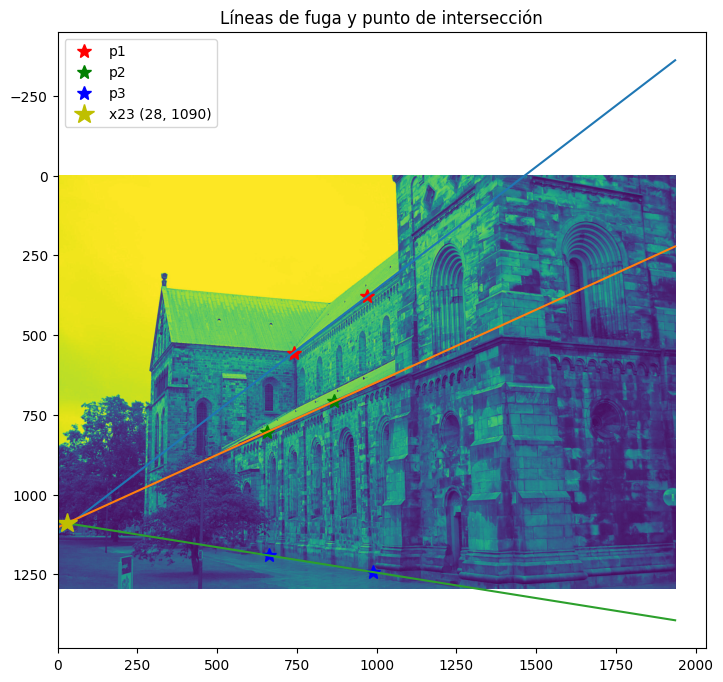

La distancia de x23 a lp1 es 8.27


In [9]:
# Computer Exercise 2 - Solution.

# You will use this function for plotting the lines
def linePoints(line = [0, 0, 0], ref = [-1.,1.]):
    """given a,b,c for straight line as ax+by+c=0,
    return and plot a pair of points based on ref values
    e.g linePoints(-1,1,2) == [[-1.0, -3.0], [1.0, -1.0]]
    """
    a = line[0]
    b = line[1]
    c = line[2]
    if (a==0 and b==0):
      raise Exception("linePoints: a and b cannot both be zero")
    else:
      points = np.array([[-c/a,p] if b==0 else [p,(-c-a*p)/b] for p in ref])
      plt.plot(points[:, 0], points[:, 1])
      return points

DATA_URL = 'https://github.com/agmarrugo/computer-vision-utb/blob/main/data/compEx2.npz?raw=true'
IMAGE_URL = 'https://github.com/agmarrugo/computer-vision-utb/blob/main/data/compEx2.JPG?raw=true'

urllib.request.urlretrieve(DATA_URL, 'compEx2.npz')
urllib.request.urlretrieve(IMAGE_URL, 'compEx2.JPG')

data = np.load('compEx2.npz')

p1 = data['p1']
p2 = data['p2']
p3 = data['p3']

# image = load image from IMAGE_URL

# plt.imshow(image)
# plt.plot(p1[0,:], p1[1,:], 'r*')
# plot remaining points

# plt.show()

# Use np.cross to calculate the lines lp1, lp2, and lp3
# Plot the lines using the function linePoints

# Use np.cross to calculate the intersection x23 of lines lp2 and lp3
# Plot the intersection

# Calculate the distance from the intersection x23 to the line lp1
# Use the above equation

# Print the result
# print('The distance from x23 to lp1 is %2.2f' % d)

# Cargar imagen
image = io.imread('compEx2.JPG')

# ── Calcular líneas con producto cruz ──────────────────────────────────────────
# Cada columna de p1, p2, p3 es un punto homogéneo (3,)
# La línea que pasa por dos puntos: l = x1 × x2
lp1 = np.cross(p1[:, 0], p1[:, 1])
lp2 = np.cross(p2[:, 0], p2[:, 1])
lp3 = np.cross(p3[:, 0], p3[:, 1])

# ── Intersección de lp2 y lp3 ─────────────────────────────────────────────────
x23 = np.cross(lp2, lp3)
x23_cart = pflat(x23.reshape(3, 1))   # convertir a cartesianas
x23_x, x23_y = x23_cart[0, 0], x23_cart[1, 0]

# ── Distancia del punto x23 a la línea lp1 ────────────────────────────────────
a, b, c = lp1
d = abs(a * x23_x + b * x23_y + c) / np.sqrt(a**2 + b**2)

# ── Graficar ──────────────────────────────────────────────────────────────────
W = image.shape[1]   # ancho de la imagen (para rango de referencia)

plt.figure(figsize=(12, 8))
plt.imshow(image)

# Puntos
plt.plot(p1[0, :], p1[1, :], 'r*', markersize=10, label='p1')
plt.plot(p2[0, :], p2[1, :], 'g*', markersize=10, label='p2')
plt.plot(p3[0, :], p3[1, :], 'b*', markersize=10, label='p3')

# Líneas (ref cubre el ancho de la imagen)
ref = [0, W]
linePoints(lp1, ref=ref)   # roja  (por defecto ciclo de colores matplotlib)
linePoints(lp2, ref=ref)   # verde
linePoints(lp3, ref=ref)   # azul

# Punto de intersección
plt.plot(x23_x, x23_y, 'y*', markersize=15, label=f'x23 ({x23_x:.0f}, {x23_y:.0f})')

plt.legend()
plt.title('Líneas de fuga y punto de intersección')
plt.show()

print('La distancia de x23 a lp1 es %2.2f' % d)

## Projective transformations

### Exercise 3   

Let $H$ be the projective transformation

\begin{align}
H =
\left(
\begin{array}{ccc}
1 & 1 & 0 \\
0 & 1 & 0 \\
-1 & 0 & 1 \\
\end{array}
\right) \enspace.
\end{align}

Compute the transformations $\mathbf{y_1} \sim H\mathbf{x_1}$ and $\mathbf{y_2} \sim H\mathbf{x_2}$ if

\begin{align}
\mathbf{x_1} = \left(
\begin{array}{c}
1\\
0\\
1\\
\end{array}
\right)
, \enspace \text{and }
\mathbf{x_2} = \left(
\begin{array}{c}
0\\
1\\
1\\
\end{array}
\right)
.\enspace
\end{align}

Compute the lines $l_1$, $l_2$ containing $\mathbf{x_1}$, $\mathbf{x_2}$, and $\mathbf{y_1}$, $\mathbf{y_2}$, respectively.

Compute $(H^{-1})^T l_1$ and compare to $l_2$.

*For the report: Submit the answers.*

### Computer Exercise 3

The file `compEx3.npz` contains the start and end points of a set of lines. Plotting the lines gives the grid shown in the figure below.

For each of the projective mappings given by the matrices

\begin{align}
H_1 =
\left(
\begin{array}{ccc}
\sqrt{3} & -1 & 1 \\
1 & \sqrt{3} & 1 \\
0 & 0 & 2 \\
\end{array}
\right), \enspace \text{and }
H_2 =
\left(
\begin{array}{ccc}
1 & -1 & 1 \\
1 & 1 & 0 \\
0 & 0 & 1 \\
\end{array}
\right)
\enspace,
\end{align}

\begin{align}
H_3 =
\left(
\begin{array}{ccc}
1 & 1 & 0 \\
0 & 2 & 0 \\
0 & 0 & 1 \\
\end{array}
\right), \enspace \text{and }
H_4 =
\left(
\begin{array}{ccc}
\sqrt{3} & -1 & 1 \\
1 & \sqrt{3} & 1 \\
1/4 & 1/2 & 2 \\
\end{array}
\right)
\enspace,
\end{align}

compute the transformations of the given start and endpoints and plot the lines between them. (Note that you do not need to loop over the points. One matrix multiplication for the start and end points is enough. To compute cartesian coordinates you can use your `pflat` function. Don’t forget to use the `plt.axis('equal')` command, otherwise the figures might look distorted.)

Which of the transformations preserve lengths between points? Which preserve angles between lines? Which maps parallel lines to parallel lines? Classify the transformations into euclidean, similarity, affine and projective transformations.

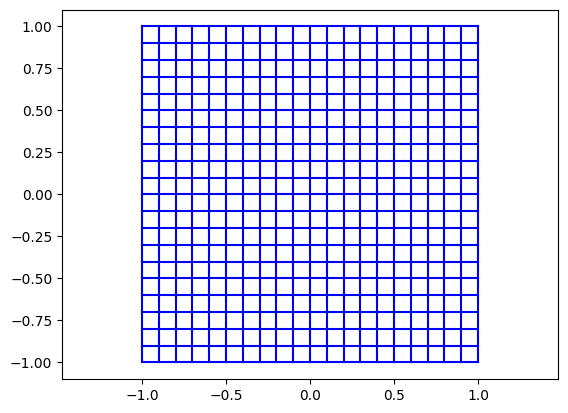

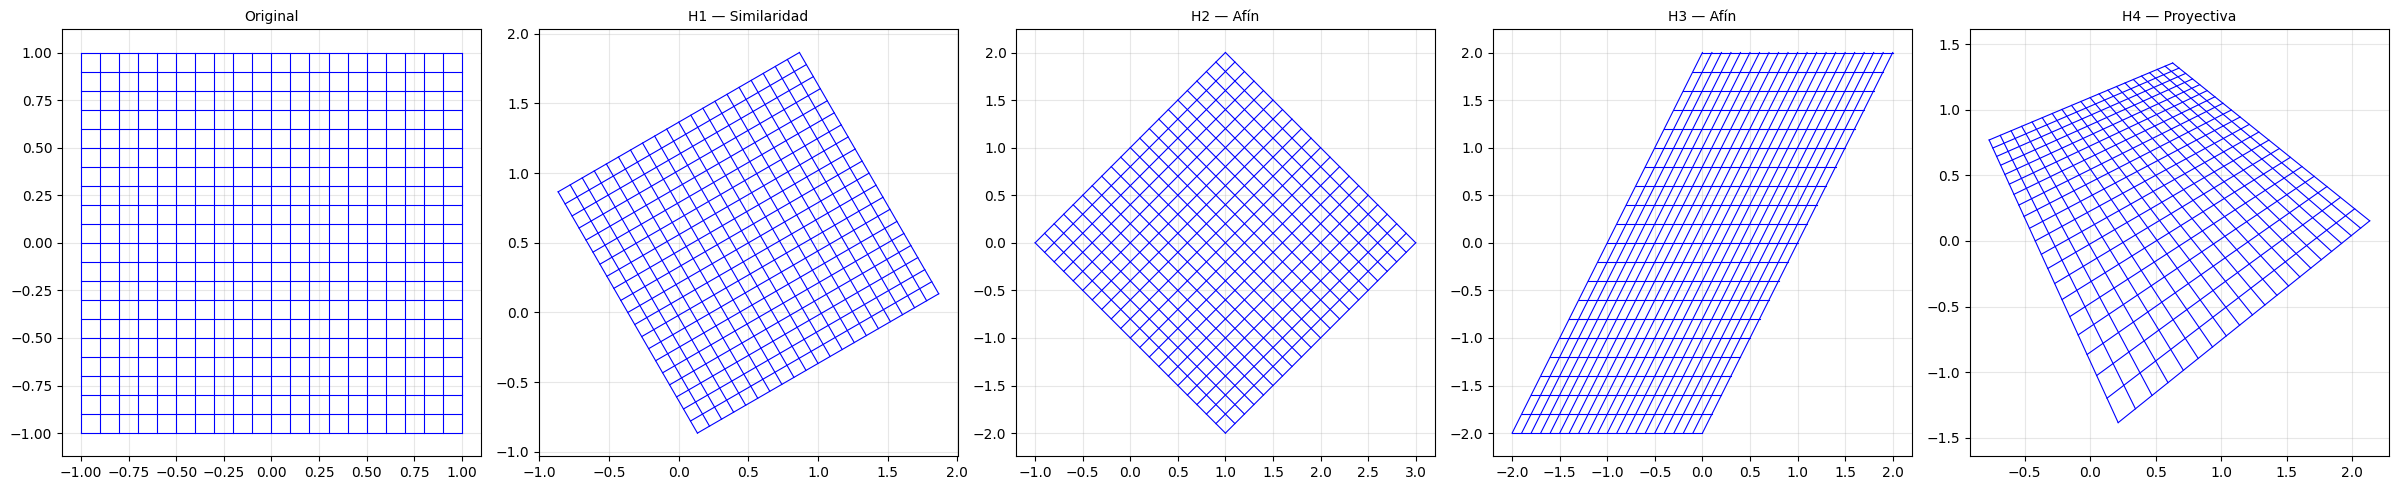

In [10]:
# Computer Exercise 3 - Solution.

DATA_URL = 'https://github.com/agmarrugo/computer-vision-utb/blob/main/data/compEx3.npz?raw=true'

import urllib.request
urllib.request.urlretrieve(DATA_URL, 'compEx3.npz')

data = np.load('compEx3.npz')

startpoints = data['startpoints']
endpoints = data['endpoints']

# Plot the grid
plt.plot([startpoints[0, :], endpoints[0, :]], [startpoints[1, :], endpoints[1, :]], 'b-')
plt.axis('equal')
plt.show()

# Build the transformation matrices
H1 = np.array([[np.sqrt(3), -1, 1], [1, np.sqrt(3), 1], [0, 0, 2]])

# Make the points homogeneous points (remember to add a row of 1s)

# Transform the points by matrix multiplication (remember to use the @ operator)

# Convert back to cartesian coordinates. You can use your pflat() function

# Include one plot per each transformation matrix
H2 = np.array([[1, -1, 1],
               [1,  1, 0],
               [0,  0, 1]], dtype=float)

H3 = np.array([[1, 1, 0],
               [0, 2, 0],
               [0, 0, 1]], dtype=float)

H4 = np.array([[np.sqrt(3), -1,          1  ],
               [1,           np.sqrt(3), 1  ],
               [1/4,         1/2,        2  ]])

# ── Convertir a coordenadas homogéneas (agregar fila de 1s) ───────────────────
N = startpoints.shape[1]
ones = np.ones((1, N))

startH = np.vstack([startpoints, ones])   # (3, N)
endH   = np.vstack([endpoints,   ones])   # (3, N)

# ── Graficar original + 4 transformaciones ────────────────────────────────────
titles = ['Original', 'H1 — Similaridad', 'H2 — Afín',
          'H3 — Afín', 'H4 — Proyectiva']
matrices = [np.eye(3), H1, H2, H3, H4]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, title, H in zip(axes, titles, matrices):
    # Transformar y convertir a cartesianas
    S = pflat(H @ startH)   # (2, N)
    E = pflat(H @ endH)     # (2, N)

    # Dibujar líneas
    ax.plot([S[0, :], E[0, :]], [S[1, :], E[1, :]], 'b-', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.axis('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()